# Configs

In [1]:
import random
import numpy as np
import torch


RANDOM_SEED = 17


random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


aeStruct = [
    (7, 8, 16),
    (8, 4, 32),
    (4, 4, 64),
]

# Auto encoder

## Read data

In [ ]:
from data_reader.data import listTurbines


turbines = listTurbines()
turbines

In [ ]:
# from preprocess.transform_to_3d import TurbineData


# turbines = listTurbines()
# turbineDatas = [TurbineData(turbine, verbose=False) for turbine in turbines]
# commonCols = set(turbineDatas[0].columns).intersection(
#     *[turbineData.columns for turbineData in turbineDatas]
# )
# print(f"Common columns: {sorted(commonCols)}")

## Split train test

In [4]:
from data_reader.data import getDataRange
from preprocess.normalize import createFeatureTransformer


targetFeatRange = getDataRange()
# targetFeats = ["avgwindspeed"]
targetFeats = list(targetFeatRange.keys())

immuteFeats = [
    "datetime",
    "underperformanceprobability",
    "normalbehaviour",
]

angleFeats = ["avgwinddirection"]  # TODO: ["avgwinddirection"]

rangedFeatRanges = {k: targetFeatRange[k] for k in targetFeats if k not in angleFeats}

transformer = createFeatureTransformer(
    rangedFeatRanges=rangedFeatRanges,
    angleFeats=angleFeats,
    immuteFeats=[],  # immuteFeats are handled below
)

In [ ]:
import pandas as pd
from preprocess.cls_dataset import TurbineDataset
from preprocess.split_data import splitIndices
from preprocess.transform_to_3d import generateStackedTurbineData


N_STEPS_PER_SAMPLE = 128
TEST_RATIO = 0.2
VAL_RATIO = 0.2

trainSets = []
valSets = []
testSets = []

abnTrainSets = []
abnTestSets = []


def evalUnderperformValid(
    data2dDf: pd.DataFrame,
):
    maxConsecutiveInvalid = 0
    maxInvalid = 0.5 * len(data2dDf)

    invalidMask = (
        (data2dDf["underperformanceprobabilityvalid"] == 0)
        | (data2dDf["underperformanceprobabilityvalid"].isna())
        | (data2dDf["original_feature_count"] == 0)
    )

    nContinousInvalid = 0
    nInvalid = 0
    for invalidNess in invalidMask:
        if invalidNess is True:
            nInvalid += 1
            nContinousInvalid += 1

            if nContinousInvalid > maxConsecutiveInvalid:
                return False
            if nInvalid > maxInvalid:
                return False

        else:
            nContinousInvalid = 0

    # check if last step is valid
    return not invalidMask.iloc[-1]


def evalNorm_Valid(
    data2dDf: pd.DataFrame,
):
    if evalUnderperformValid(data2dDf) is False:
        return False

    normalness = data2dDf["normalbehaviour"].astype(bool)
    # normal if at least 99% of the data is normal
    return normalness.sum() >= np.floor(len(normalness) * 0.99)


def evalAbn_Valid(
    data2dDf: pd.DataFrame,
):
    if evalUnderperformValid(data2dDf) is False:
        return False

    normalness = data2dDf["normalbehaviour"].astype(bool)
    # abnormal if at least 1% of the data is abnormal
    return ~(normalness.sum() >= np.floor(len(normalness) * 0.99))


lastIndexer = None
for turbine in turbines:
    print(f"Processing turbine: {turbine}")

    indexer, (dataNorm, dataAbn) = generateStackedTurbineData(
        turbine,
        n_timesteps=N_STEPS_PER_SAMPLE,
        conditions=[evalNorm_Valid, evalAbn_Valid],
    )

    print(f"Normal valid data: {dataNorm.shape[0]}")
    print(f"Abnormal valid data: {dataAbn.shape[0]}")

    # split normal to train, val, test
    trainIndices, valIndices, testIndices = splitIndices(
        list(range(dataNorm.shape[0])),
        testRatio=TEST_RATIO,
        valRatio=VAL_RATIO,
    )
    trainSet = TurbineDataset.from3dNumpy(
        dataNorm, indexer, targetFeats, transformer, immuteFeats, trainIndices
    )
    valSet = TurbineDataset.from3dNumpy(
        dataNorm, indexer, targetFeats, transformer, immuteFeats, valIndices
    )
    testSet = TurbineDataset.from3dNumpy(
        dataNorm, indexer, targetFeats, transformer, immuteFeats, testIndices
    )

    abnTrainIndices, abnValIndices, abnTestIndices = splitIndices(
        list(range(dataAbn.shape[0])),
        testRatio=TEST_RATIO,
        valRatio=VAL_RATIO,
    )
    abnTrainSet = TurbineDataset.from3dNumpy(
        dataAbn, indexer, targetFeats, transformer, immuteFeats, abnTrainIndices
    )
    abnValSet = TurbineDataset.from3dNumpy(
        dataAbn, indexer, targetFeats, transformer, immuteFeats, abnValIndices
    )
    abnTestSet = TurbineDataset.from3dNumpy(
        dataAbn, indexer, targetFeats, transformer, immuteFeats, abnTestIndices
    )

    trainSets.append(trainSet)
    valSets.append(valSet)
    testSets.append(testSet)

    abnTrainSets.append(abnTrainSet)
    abnTestSets.append(abnTestSet)

    if lastIndexer is not None and lastIndexer != indexer:
        raise ValueError(
            f"At turbine {turbine}, indexer changed from {lastIndexer} to {indexer}. "
        )
    lastIndexer = indexer

    print("=" * 50)

## Create data loader

In [6]:
from torch.utils.data import DataLoader

from preprocess.cls_dataset import IMMUTE_GROUP, TARGET_GROUP, TurbineDataset


BATCH_SIZE = 96

# check if trainSets is unbound
try:
    trainSet = TurbineDataset.merge(trainSets)
    valSet = TurbineDataset.merge(valSets)
    testSet = TurbineDataset.merge(testSets)

    abnTrainSet = TurbineDataset.merge(abnTrainSets)
    abnTestSet = TurbineDataset.merge(abnTestSets)

    # # save the datasets
    # trainSet.save("tmp/full_train_set")
    # valSet.save("tmp/full_val_set")
    # testSet.save("tmp/full_test_set")
    # abnormalTestSet.save("tmp/full_abnormal_test_set")
    # print("Merged and saved datasets successfully.")

except NameError as e:
    raise e
    # print("The composite dataset is not defined. Try loading the datasets from files.")
    # trainSet = TurbineDataset.load("tmp/full_train_set")
    # valSet = TurbineDataset.load("tmp/full_val_set")
    # testSet = TurbineDataset.load("tmp/full_test_set")
    # abnTestSet = TurbineDataset.load("tmp/full_abnormal_test_set")

print(
    f"Normal/Abnormal ratio: {(len(trainSet) + len(valSet) + len(testSet)) / (len(abnTrainSet) + len(abnValSet) + len(abnTestSet))}"
)


indexer = trainSet.indexer

trainLoader = DataLoader(
    TurbineDataset.merge([trainSet, abnTrainSet]),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
)
valLoader = DataLoader(
    TurbineDataset.merge([valSet, abnValSet]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)
testLoader = DataLoader(
    TurbineDataset.merge([testSet, abnTestSet]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

targetFeats = indexer.getGroupTags(TARGET_GROUP)
print(f"Target features: {targetFeats}")

immuteFeats = indexer.getGroupTags(IMMUTE_GROUP)
print(f"Immute features: {immuteFeats}")

first_batch = next(iter(trainLoader))
inputShape = np.array(first_batch[0].size())
inputShape[0] = len(targetFeats)

# model latent space
n_feat = len(targetFeats)
## reduce the n_feat by n_decompressed feats
sin_feats = [f[:-4] for f in targetFeats if f.endswith("_sin")]  # type: ignore
cos_feats = [f[:-4] for f in targetFeats if f.endswith("_cos")]  # type: ignore
n_decompressed = len(set(sin_feats + cos_feats))


print(f"inputShape: {inputShape}")

Normal/Abnormal ratio: 2.0247009880395215
Target features: ['avgpower', 'avgrotorspeed', 'avgwindspeed', 'density', 'ambienttemperature', 'avgwinddirection_sin', 'avgwinddirection_cos']
Immute features: ['datetime', 'underperformanceprobability', 'normalbehaviour']
inputShape: [  7 128]


## Validate model

In [7]:
import torch
import torch.nn as nn
from torchinfo import summary
from model_options.mama.cnn_latent import Autoencoder
from model_options.multihead.regressive_wrapper import MultiHeadAEWrapper


# test if the model is working
tmp = Autoencoder(aeStruct)
testModel = MultiHeadAEWrapper(tmp)

summary(
    testModel, torch.Size((96, inputShape[0], inputShape[1])), depth=7, device="cpu"
)

Layer (type:depth-idx)                                       Output Shape              Param #
MultiHeadAEWrapper                                           [96, 7, 128]              --
├─Autoencoder: 1-1                                           --                        --
│    └─Sequential: 2-1                                       [96, 4, 16]               --
│    │    └─Encoder: 3-1                                     [96, 8, 64]               --
│    │    │    └─Sequential: 4-1                             [96, 16, 64]              --
│    │    │    │    └─MultiScaleAttentionBlock1D: 5-1        [96, 16, 64]              --
│    │    │    │    │    └─Sequential: 6-1                   [96, 48, 128]             --
│    │    │    │    │    │    └─Conv1d: 7-1                  [96, 48, 128]             384
│    │    │    │    │    │    └─BatchNorm1d: 7-2             [96, 48, 128]             96
│    │    │    │    │    │    └─ReLU: 7-3                    [96, 48, 128]             --
│   

## Training 

### Train Injections

In [8]:
def inferBatch(batch, model):

    # reshapre to (batch, feats as channels, timesteps)
    imm = indexer.slice(batch, immuteFeats, dim=1)
    inp = indexer.slice(batch, targetFeats, dim=1)

    reconst, pred = model(inp)
    label = indexer.slice(batch, ["normalbehaviour"], dim=1)
    # rm feat dim (d=1)  # (batch, 1)
    label = label.squeeze(1).sum(dim=1, keepdim=True) >= 127
    # check next cell for explanation of 127
    label = label.float()

    return torch.cat((reconst, imm), dim=1), torch.cat((inp, imm), dim=1), pred, label

In [9]:
n_norm = indexer.slice(trainSet.items, ["normalbehaviour"], dim=1).sum(2).squeeze(1)
minN_norm = n_norm.min()
maxN_norm = n_norm.max()
stdN_norm = n_norm.std()
meanN_norm = n_norm.mean()

print(
    f"Normalness: min={minN_norm}, max={maxN_norm}, std={stdN_norm}, mean={meanN_norm}"
)

# weighting by std normalizing  will lead to bad loss function
# manually change std and mean
stdN_norm = 1
meanN_norm = 127
# after weighting, 127 -> 0.5; 128+ -> 1.0; others -> 0


# cal weight for reconstruction loss
def weightCal(pred, actual):
    normalness = indexer.slice(actual, ["normalbehaviour"], dim=1)
    # batch, 1, timesteps

    # halfN_timeSteps = normalness.shape[2] / 2
    totalNorm = normalness.sum(dim=2, keepdim=True)

    # convert to std range of -1 -> 1
    weight = (totalNorm - meanN_norm) / stdN_norm
    # convert to 0 -> 1 range
    weight = (weight + 1) / 2
    # clip weight
    weight = torch.nan_to_num(weight, nan=0, posinf=1, neginf=0.0)
    weight = torch.clamp(weight, min=0.0, max=1.0)

    return weight

Normalness: min=126.0, max=128.0, std=0.0926712304353714, mean=127.99459075927734


### Loop

In [10]:
import datetime
from matplotlib import pyplot as plt
import torch.optim as optim

from train.loss import SampleWeightedLoss, TargetedLoss
from train.trainer import infer, train


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


model = MultiHeadAEWrapper(Autoencoder(aeStruct))

# use mean average error
rawLoss = nn.MSELoss(reduction="none")
targetedLoss = TargetedLoss(rawLoss, indexer.getIdx(targetFeats))
weightedLoss = SampleWeightedLoss(targetedLoss, weightCal)


class MultiHeadLoss(nn.Module):
    def __init__(self):
        super(MultiHeadLoss, self).__init__()

        # for reconstruction loss
        self.loss1 = weightedLoss

        # for prediction loss
        self.loss2 = nn.BCEWithLogitsLoss()

        # TODO: auto weighting 2 losses

    def forward(self, reconst, org, pred, actual):
        reconstLoss = self.loss1(reconst, org)

        predLoss = self.loss2(pred, actual)

        return reconstLoss + 0*predLoss


criterion = MultiHeadLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
earlyStopping = 10

trainLosses = []
valLosses = []


def abnormErrCal(model, valOuts, *_, **__):
    pred, actual, *_ = valOuts
    weight = weightCal(pred, actual)

    # retain only samples with weight <= 0
    weight = weight.squeeze()
    pred = pred[weight <= 0]
    actual = actual[weight <= 0]

    pred = indexer.slice(pred, targetFeats, dim=1)
    actual = indexer.slice(actual, targetFeats, dim=1)

    return torch.square((pred - actual)).mean()


def normErrCal(model, valOuts, *_, **__):
    pred, actual, *_ = valOuts
    weight = weightCal(pred, actual)

    # retain only samples with weight > 0
    weight = weight.squeeze()
    pred = pred[weight > 0.1]
    actual = actual[weight > 0.1]

    pred = indexer.slice(pred, targetFeats, dim=1)
    actual = indexer.slice(actual, targetFeats, dim=1)

    return torch.square((pred - actual)).mean()


model, trainLosses, valLosses, info = train(
    model,
    device,
    trainLoader,
    valLoader,
    criterion,
    optimizer,
    epochs=num_epochs,
    earlyStopping=earlyStopping,
    inferBatch=inferBatch,
    verbose=False,
    trackVars={
        "abnormalErr": abnormErrCal,
        "normalErr": normErrCal,
    },
)
# save model
torch.save(
    model.state_dict(),
    f"output/simple_extended_model_{datetime.datetime.now().strftime('%M:%H_%m-%d')}.pth",
)

Device: cuda


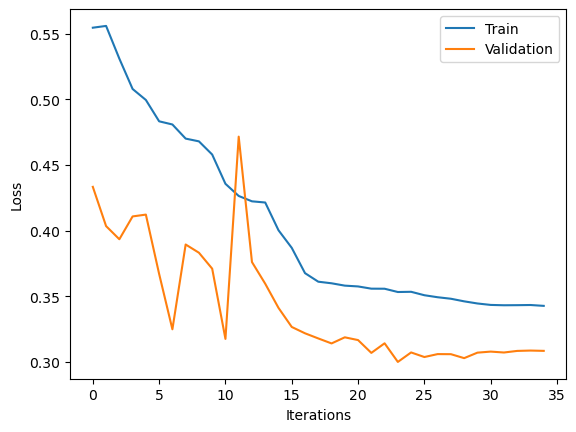

In [11]:
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.plot(trainLosses[10:])
plt.plot(valLosses[10:])

plt.legend(["Train", "Validation", "Abnormal"])
plt.show()

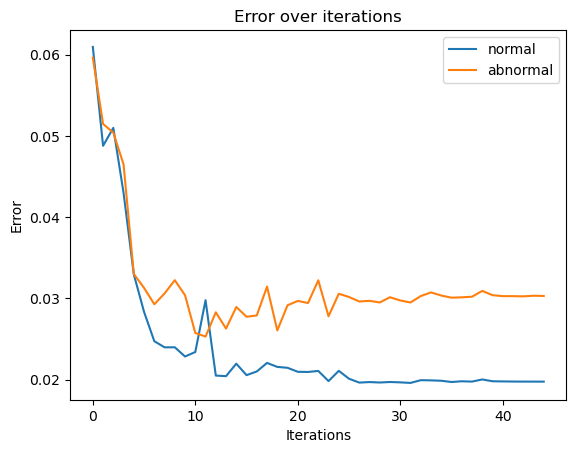

In [12]:
abnErr = info["abnormalErr"]
abnErr = [i.item() for i in abnErr]

normErr = info["normalErr"]
normErr = [i.item() for i in normErr]

plt.plot(normErr)
plt.plot(abnErr)

plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend(["normal", "abnormal"])
plt.title("Error over iterations")
plt.show()

## Evaluating

### Reconst MAE

In [13]:
from preprocess.normalize import decodeAngles
from train.trainer import infer


reconsts, orgs, isNormPred, isNormActual = infer(model, device, testLoader, inferBatch)

# filter the reconstructed and original data for "normalbehaviour" sum >= 127 only
isNormArr = indexer.slice(orgs, ["normalbehaviour"], dim=1)
isNormMask = isNormArr.squeeze(1).sum(dim=1) >= 127
reconsts = reconsts[isNormMask]
orgs = orgs[isNormMask]

circularFeats = ["avgwinddirection"]
skipFeats = []
errs = []
for feat in targetFeats:
    if feat in skipFeats:
        continue

    assert isinstance(feat, str), f"Feature {feat} is not a string"
    featIndex = indexer[feat]
    print(f"Feature {feat} :")

    if feat in circularFeats:
        featErr = torch.sub(
            reconsts[:, featIndex : (featIndex + 1), :],
            orgs[:, featIndex : (featIndex + 1), :],
        )
        featErr = torch.where(
            featErr > 0.5,
            featErr - 1,
            torch.where(featErr < -0.5, featErr + 1, featErr),
        )

    elif feat.endswith("_sin") or feat.endswith("_cos"):
        print(f"Feature {feat[:-4]} :")

        sinFeat = feat[:-4] + "_sin"
        cosFeat = feat[:-4] + "_cos"
        skipFeats.append(sinFeat)
        skipFeats.append(cosFeat)

        sinIndex = indexer[sinFeat]
        cosIndex = indexer[cosFeat]

        # transform sin and cos data to n * time_steps, 2
        sinRec = reconsts[:, sinIndex : (sinIndex + 1), :].reshape(-1, 1)
        cosRec = reconsts[:, cosIndex : (cosIndex + 1), :].reshape(-1, 1)

        sinOrg = orgs[:, sinIndex : (sinIndex + 1), :].reshape(-1, 1)
        cosOrg = orgs[:, cosIndex : (cosIndex + 1), :].reshape(-1, 1)

        angleRec = torch.cat((sinRec, cosRec), dim=1)
        angleOrg = torch.cat((sinOrg, cosOrg), dim=1)

        # run through decodeAngles (n * time_steps, 1)
        angleRec = decodeAngles(angleRec.cpu().numpy())
        angleOrg = decodeAngles(angleOrg.cpu().numpy())

        # transform back to n, 1, time_steps
        angleRec = angleRec.reshape(reconsts.size(0), 1, reconsts.size(2))
        angleOrg = angleOrg.reshape(orgs.size(0), 1, orgs.size(2))

        # calculate error like in circular feats but for 360 instead of 1
        featErr = angleRec - angleOrg
        featErr = (
            np.where(
                featErr > 180,
                featErr - 360,
                np.where(featErr < -180, featErr + 360, featErr),
            )
            / 360.0
        )
        featErr = torch.tensor(featErr, device=device)
    else:
        featErr = torch.sub(
            reconsts[:, featIndex : (featIndex + 1), :],
            orgs[:, featIndex : (featIndex + 1), :],
        )

    errs.append(featErr)

    print(f"\tMean: {featErr.mean().item()}")
    print(f"\tStd: {featErr.std().item()}")
    print(f"\tMax: {featErr.max().item()}")
    print(f"\tMin: {featErr.min().item()}")
    print(f"\tMean abs: {featErr.abs().mean().item()}")

errs = torch.stack(errs, dim=1)
print(f"Test MAE: {errs.abs().mean().mean().item()}")

Feature avgpower :
	Mean: -0.01032146718353033
	Std: 0.14516013860702515
	Max: 0.8127796649932861
	Min: -0.8679399490356445
	Mean abs: 0.10607776790857315
Feature avgrotorspeed :
	Mean: -0.0025419709272682667
	Std: 0.09201488643884659
	Max: 0.6661731600761414
	Min: -0.47299057245254517
	Mean abs: 0.06685207039117813
Feature avgwindspeed :
	Mean: -0.006137865129858255
	Std: 0.10348048061132431
	Max: 0.4816140830516815
	Min: -0.8713890314102173
	Mean abs: 0.07873097062110901
Feature density :
	Mean: 0.009220062755048275
	Std: 0.10723389685153961
	Max: 0.605968177318573
	Min: -0.5088292360305786
	Mean abs: 0.0752764344215393
Feature ambienttemperature :
	Mean: 0.004068918991833925
	Std: 0.10950473695993423
	Max: 0.35702624917030334
	Min: -0.5045165419578552
	Mean abs: 0.08621620386838913
Feature avgwinddirection_sin :
Feature avgwinddirection :
	Mean: -0.0018529144581407309
	Std: 0.1022331565618515
	Max: 0.4998624622821808
	Min: -0.4993261694908142
	Mean abs: 0.07017293572425842
Test MAE:

### Predict normal flag

Test accuracy: 0.8767634854771784
Test recall: 0.9265463917525774
Test precision: 0.8871067242442936
Test F1: 0.9063977308540813
Test ROC AUC: 0.9384950316007017
Test AUPR: 0.9639441701127316


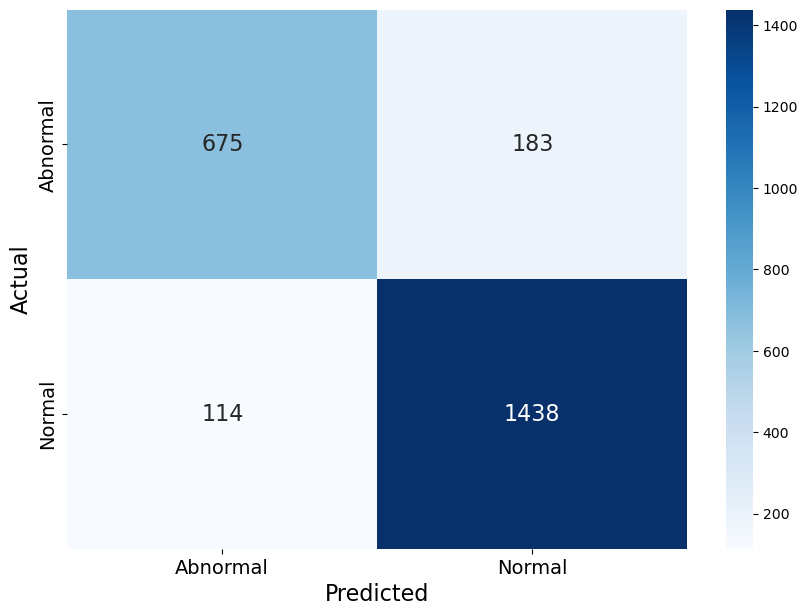

In [14]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix
import seaborn as sns


isNormPred = torch.sigmoid(isNormPred)

# calc accuracy, recall, precision, f1, roc-auc, aupr
acc = accuracy_score(
    isNormActual.cpu().numpy(),
    (isNormPred.cpu().numpy() > 0.5).astype(int),
)
recall = recall_score(
    isNormActual.cpu().numpy(),
    (isNormPred.cpu().numpy() > 0.5).astype(int),
)
precision = precision_score(
    isNormActual.cpu().numpy(),
    (isNormPred.cpu().numpy() > 0.5).astype(int),
)
f1 = f1_score(
    isNormActual.cpu().numpy(),
    (isNormPred.cpu().numpy() > 0.5).astype(int),
)
auc = roc_auc_score(
    isNormActual.cpu().numpy(),
    isNormPred.cpu().numpy(),
)
aupr = average_precision_score(
    isNormActual.cpu().numpy(),
    isNormPred.cpu().numpy(),
)

print(f"Test accuracy: {acc}")
print(f"Test recall: {recall}")
print(f"Test precision: {precision}")
print(f"Test F1: {f1}")
print(f"Test ROC AUC: {auc}")
print(f"Test AUPR: {aupr}")

## confusion matrix


confusion = confusion_matrix(
    isNormActual.cpu().numpy(),
    (isNormPred.cpu().numpy() > 0.5).astype(int),
)
plt.figure(figsize=(10, 7))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 16},
    xticklabels=["Abnormal", "Normal"],
    yticklabels=["Abnormal", "Normal"],
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("Confusion Matrix", fontsize=18)
plt.show()

### Other Reconst metrics

In [15]:
org = indexer.slice(orgs, targetFeats, dim=1)
reconst = indexer.slice(reconsts, targetFeats, dim=1)

#### Peak Signal-to-Noise Ratio

In [16]:
MAX_PIXEL = 1

mse = torch.mean((org - reconst) ** 2).item()  # type: ignore
psnr = 10 * np.log10(MAX_PIXEL / mse)
print(f"PSNR: {psnr:.4f} dB")

PSNR: 16.9917 dB


#### Maximum Mean Discrepancy

In [17]:
from torch.utils.data import TensorDataset
from ignite.engine import Engine
from ignite.metrics import MaximumMeanDiscrepancy


def compute_mmd(x, y, sigma=1.0):
    dset = TensorDataset(x, y)
    loader = DataLoader(dset, batch_size=BATCH_SIZE, shuffle=False)

    def eval_f(engine, batch):
        return batch

    eval_tor = Engine(eval_f)

    mmd = MaximumMeanDiscrepancy()
    mmd.attach(eval_tor, "mmd")

    state = eval_tor.run(loader)

    return state.metrics["mmd"]


compute_mmd(reconst, org)

/home/tu/micromamba/envs/nbm/lib/python3.12/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


0.07025498151779175

#### Wasserstein

In [18]:
from scipy.stats import wasserstein_distance


def compute_wasserstein(x, y):
    x_flat = x.reshape(x.shape[0], -1)
    y_flat = y.reshape(y.shape[0], -1)
    dists = [
        wasserstein_distance(x_flat[:, i], y_flat[:, i]) for i in range(x_flat.shape[1])
    ]
    return np.mean(dists)


compute_wasserstein(org.cpu().numpy(), reconst.cpu().numpy())

np.float64(0.04094487853212265)

#### t-NSE

In [19]:
from sklearn.manifold import TSNE


def plot_tsne(z, labels=None, title="Latent t-SNE"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    z_2d = tsne.fit_transform(z)
    plt.figure(figsize=(6, 5))
    if labels is not None:
        plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap="tab10", s=10)
    else:
        plt.scatter(z_2d[:, 0], z_2d[:, 1], s=10)
    plt.title(title)
    plt.show()


def inferBatchEnc(batch, model):

    # reshapre to (batch, feats as channels, timesteps)
    imm = indexer.slice(batch, immuteFeats, dim=1)
    inp = indexer.slice(batch, targetFeats, dim=1)

    out = model(inp)

    return out, torch.cat((inp, imm), dim=1)  # type: ignore


encoded, _ = infer(model.aeModel.encoders, device, testLoader, inferBatchEnc)
encoded = torch.tanh(encoded)  # add encoder activation
z = encoded.detach().cpu().numpy()
# plot_tsne(z)

## Reconstruct graph

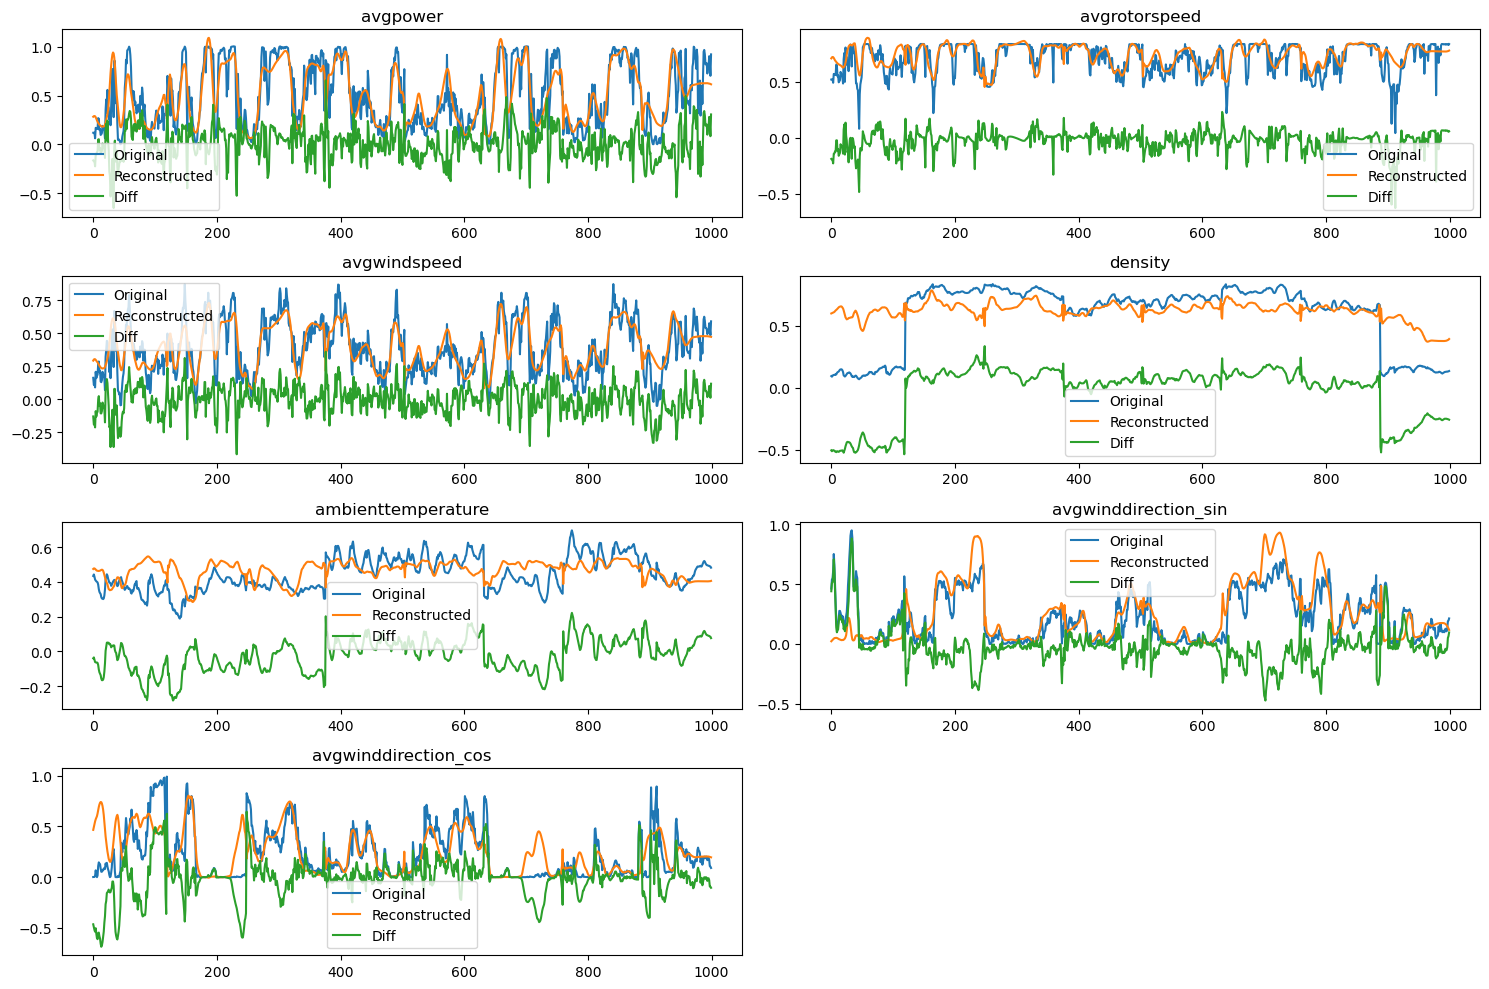

In [20]:
a = 5000
b = a + 1000

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(org[a:b], label="Original")
    plt.plot(reconst[a:b], label="Reconstructed")
    plt.plot(org[a:b] - reconst[a:b], label="Diff")
    plt.legend()
    plt.title(str(feat))
plt.tight_layout()
plt.show()

In [21]:
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats), 1, i + 1)
    plt.plot(org, label="Original")
    plt.plot(reconst, label="Reconstructed")
    plt.plot(org - reconst, label="Diff")
    plt.legend()
    plt.title(str(feat))
plt.tight_layout()
plt.savefig("output/target_feats.svg")
plt.close()

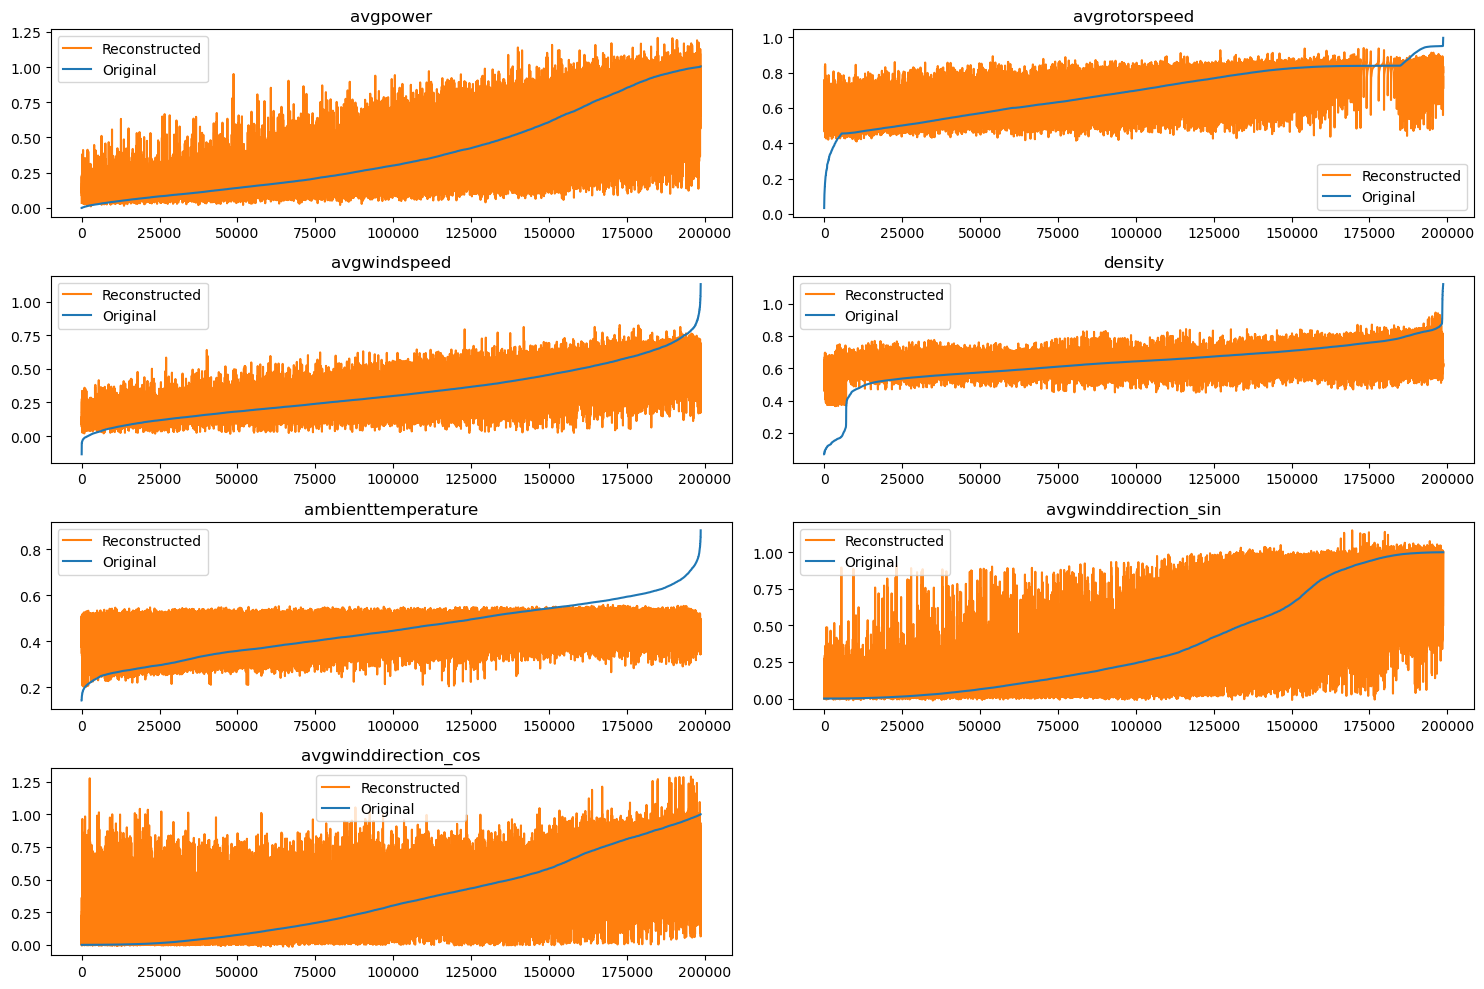

In [22]:
# plot for all targetFeats
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    sortedOrg, sortedReconst = zip(*sorted(zip(org, reconst)))

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(sortedReconst, label="Reconstructed", color="#ff7f0e")
    plt.plot(sortedOrg, label="Original", color="#1f77b4")
    plt.title(str(feat))
    plt.legend()
plt.tight_layout()
plt.show()

## [scatter] Real vs. predicted

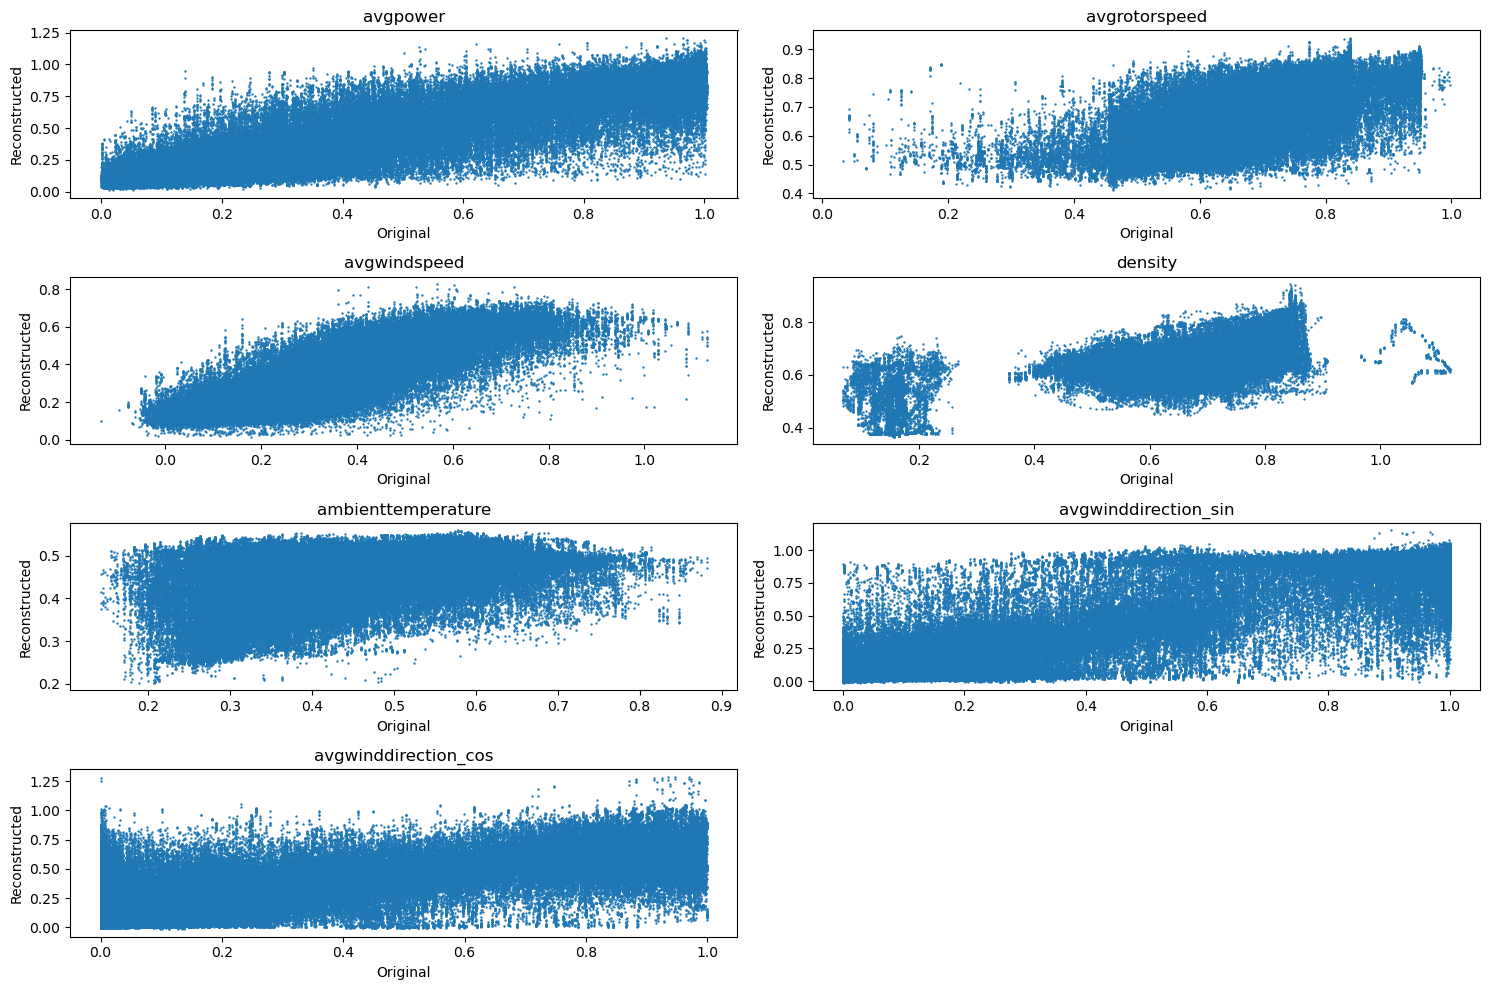

In [23]:
# scatter plot of real vs predicted for all targetFeats
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.scatter(org, reconst, s=0.5)
    plt.xlabel("Original")
    plt.ylabel("Reconstructed")
    plt.title(str(feat))
plt.tight_layout()
plt.show()

## [line] Error through time
(either MAE or MSE) + (aggregate weekly or monthly to ease visualization)

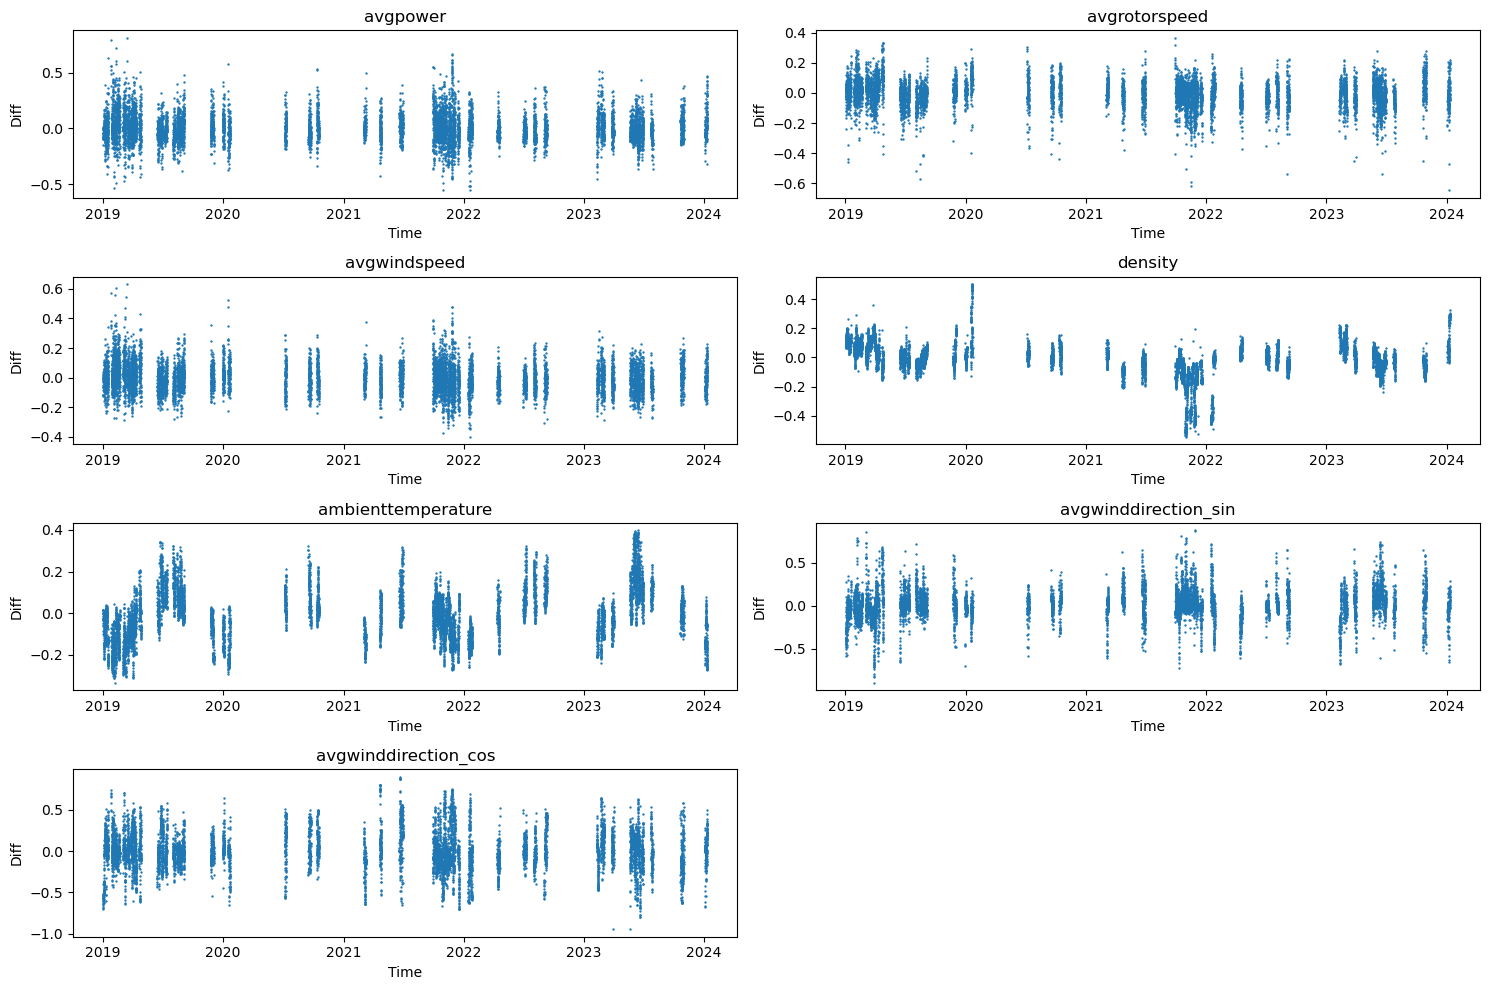

In [24]:
import datetime


timeFeat = orgs[:, indexer["datetime"], :].detach().cpu().numpy().reshape(-1)

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    diff = org - reconst

    sortedTime, diffByTime = zip(*sorted(zip(timeFeat, diff)))

    map = {}
    unkTime = 0
    for value, time in zip(diffByTime, sortedTime):
        try:
            time = datetime.datetime.fromtimestamp(float(time))
        except ValueError:
            unkTime += 1
            continue

        if time not in map:
            map[time] = (value, 1)
        else:
            map[time] = (map[time][0] + value, map[time][1] + 1)

    diffByTime = [value / count for value, count in map.values()]
    timeUniq = list(map.keys())

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.scatter(timeUniq, diffByTime, s=0.5)
    plt.title(str(feat))
    plt.xlabel("Time")
    plt.ylabel("Diff")
plt.tight_layout()
plt.show()

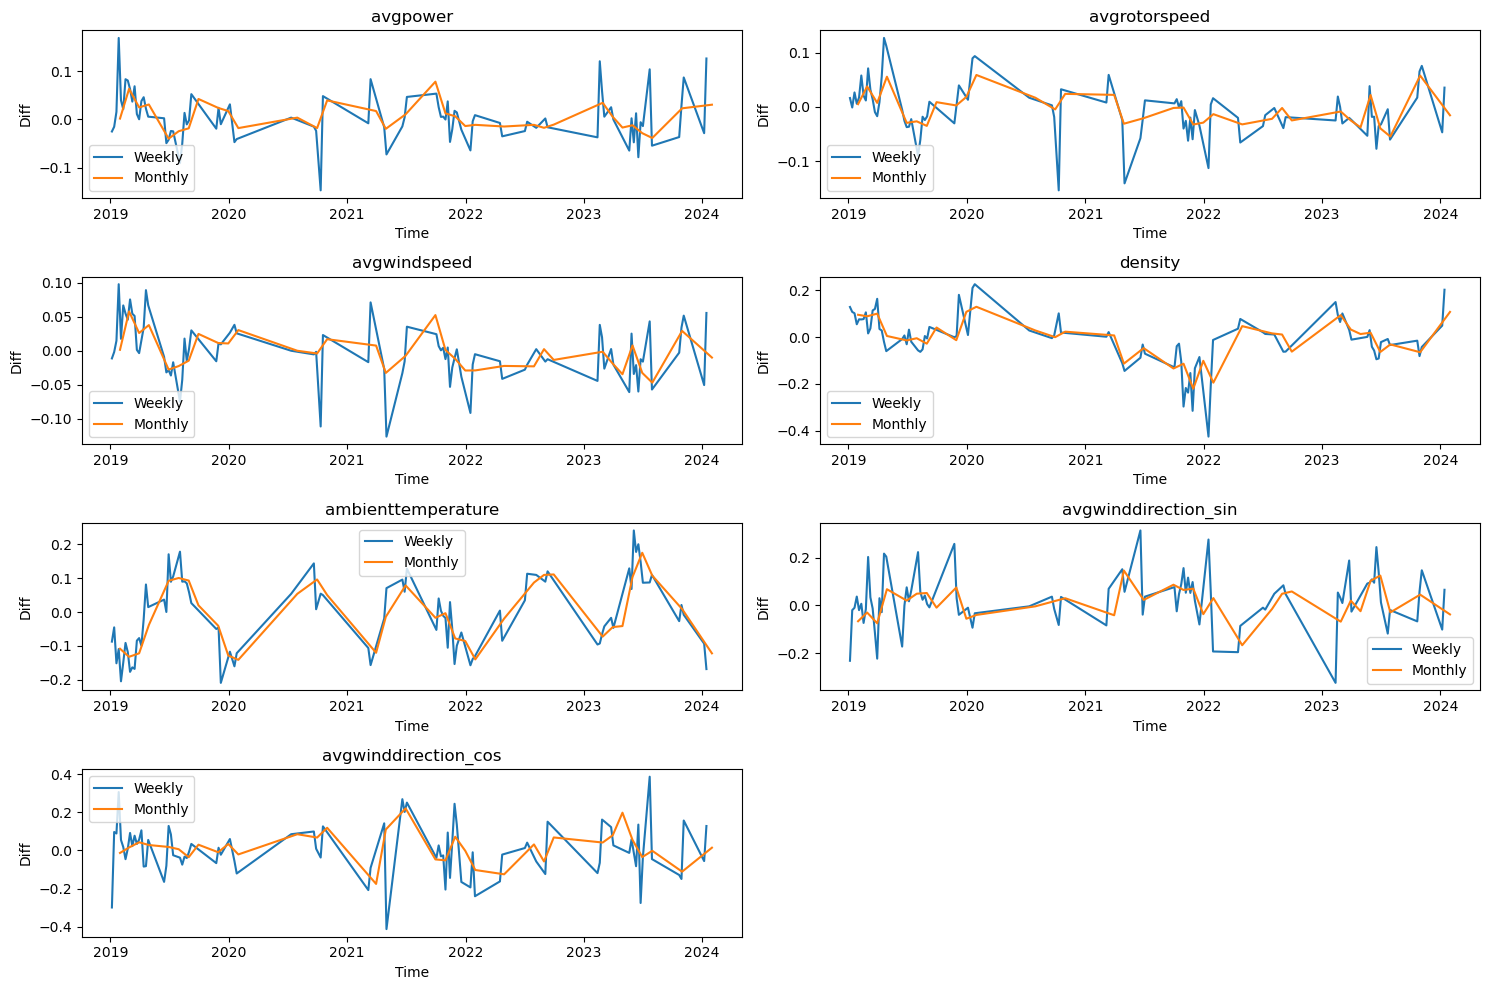

In [25]:
import pandas as pd


timeFeat = orgs[:, indexer["datetime"], :].detach().cpu().numpy().reshape(-1)

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = orgs[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = reconsts[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    diff = org - reconst

    sortedTime, diffByTime = zip(*sorted(zip(timeFeat, diff)))

    map = {}
    unkTime = 0
    for value, time in zip(diffByTime, sortedTime):
        try:
            time = datetime.datetime.fromtimestamp(float(time))
        except ValueError:
            unkTime += 1
            continue

        if time not in map:
            map[time] = (value, 1)
        else:
            map[time] = (map[time][0] + value, map[time][1] + 1)

    diffByTime = [value / count for value, count in map.values()]
    timeUniq = list(map.keys())

    dfDiff = pd.DataFrame({"time": timeUniq, "diff": diffByTime})
    dfDiff.set_index("time", inplace=True)

    dfWeek = dfDiff.resample("W").mean()
    dfWeek.dropna(inplace=True)

    dfMonth = dfDiff.resample("ME").mean()
    dfMonth.dropna(inplace=True)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(dfWeek.index, dfWeek["diff"], label="Weekly")
    plt.plot(dfMonth.index, dfMonth["diff"], label="Monthly")
    plt.title(str(feat))
    plt.xlabel("Time")
    plt.ylabel("Diff")
    plt.legend()
plt.tight_layout()
plt.show()

## [scatter] Err vs UnderProba
Error vs. underperformance probability

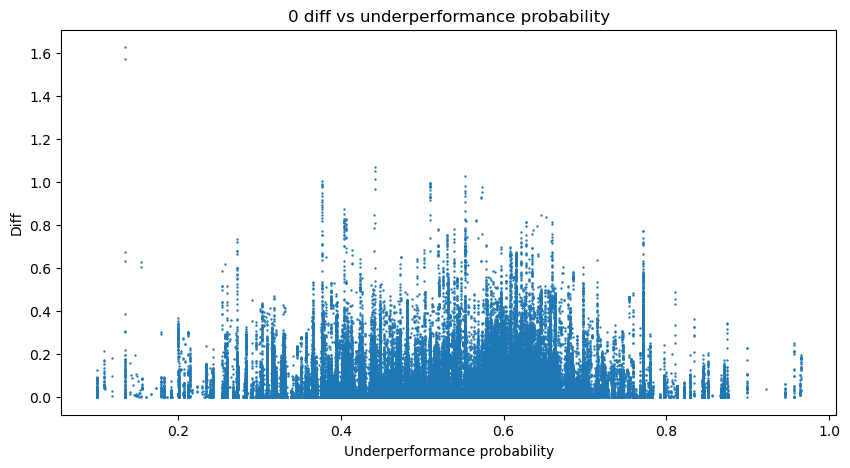

In [26]:
org = orgs[:, featIdx].detach().cpu().numpy().reshape(-1)
reconst = reconsts[:, featIdx].detach().cpu().numpy().reshape(-1)
diff = org - reconst

underProba = (
    orgs[:, indexer["underperformanceprobability"]].detach().cpu().numpy().reshape(-1)
)

plt.figure(figsize=(10, 5))
plt.scatter(underProba, diff**2, s=0.5)
plt.xlabel("Underperformance probability")
plt.ylabel("Diff")
plt.title(f"{0} diff vs underperformance probability")
plt.savefig("output/diff_vs_underperformance.pdf")
plt.show()

/tmp/ipykernel_908566/4149750145.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("binned")["diff"]


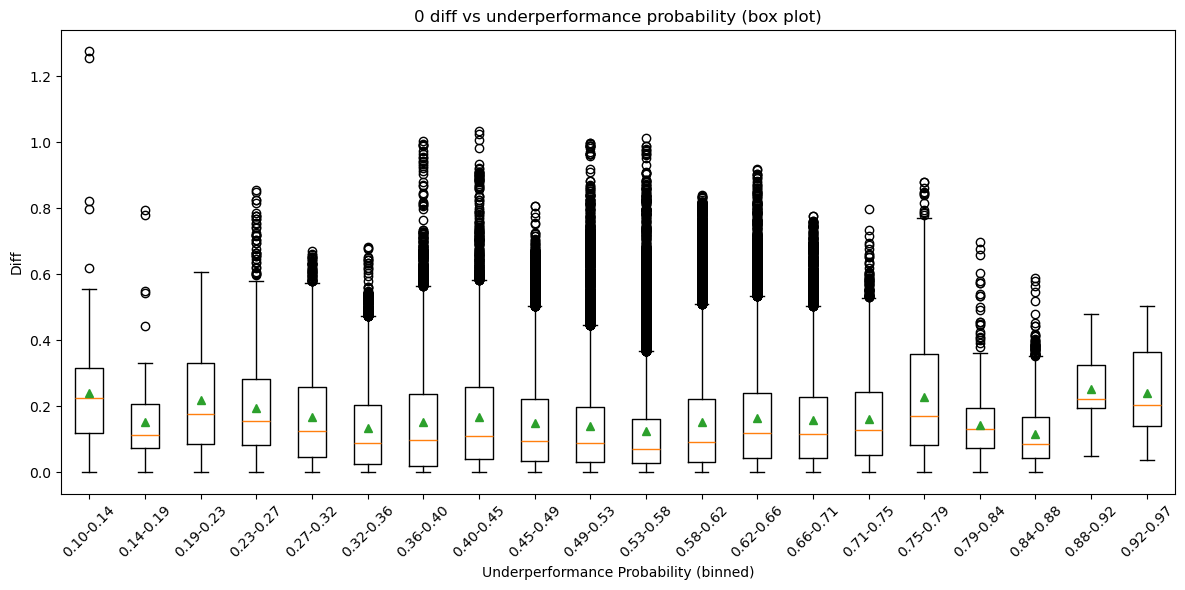

In [27]:
### Average diff by underperformance probability
df = pd.DataFrame({"underProba": underProba, "diff": np.abs(diff)})

num_bins = 20
df["binned"] = pd.cut(df["underProba"], bins=num_bins)

grouped = df.groupby("binned")["diff"]

box_data = [group for _, group in grouped]

# Create boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(box_data, showmeans=True)

# Label x-axis with bin ranges
bin_labels = [
    f"{interval.left:.2f}-{interval.right:.2f}" for interval in grouped.groups.keys()  # type: ignore
]
plt.xticks(ticks=np.arange(1, len(bin_labels) + 1), labels=bin_labels, rotation=45)

plt.xlabel("Underperformance Probability (binned)")
plt.ylabel("Diff")
plt.title(f"{0} diff vs underperformance probability (box plot)")
plt.tight_layout()
plt.show()

# Abnormal Detection

In [28]:
recons, orgs, abnAndNormUnderPerfPred, abnAndNormUnderPerfActual = infer(
    model, device, testLoader, inferBatch
)

orgFeat = indexer.slice(orgs, targetFeats, dim=1)
reconsFeat = indexer.slice(recons, targetFeats, dim=1)
reconsError = torch.abs(orgFeat - reconsFeat)

timeFlag = indexer.slice(orgs, ["datetime"], dim=1)
normalFlag = indexer.slice(orgs, ["normalbehaviour"], dim=1)

sampleNorms = []
for i0 in range(reconsError.size(0)):
    # if more than half during time steps are normal, then the sample is normal
    normalCount = normalFlag[i0, :, :].bool().sum().item()
    if normalCount > 0.5 * reconsError.size(2):
        sampleNorms.append(True)
    else:
        sampleNorms.append(False)


print("Abnorm ratio: ", 1 - np.mean(sampleNorms))

Abnorm ratio:  0.27468879668049795


In [29]:
# auc for each feature, using std
from sklearn.metrics import roc_auc_score

for i in range(reconsError.size(1)):
    feature_errors = reconsError[:, i]
    auc = roc_auc_score(sampleNorms, 1 - feature_errors.cpu().numpy().mean(axis=1))
    print(f"Feature {targetFeats[i]}: AUC = {auc:.4f}")

auc = roc_auc_score(
    sampleNorms, 1 - reconsError.cpu().numpy().mean(axis=2).mean(axis=1)
)  # max per feature, mean per day
print(f"Overall AUC: {auc:.4f}")

Feature avgpower: AUC = 0.5728
Feature avgrotorspeed: AUC = 0.6437
Feature avgwindspeed: AUC = 0.6306
Feature density: AUC = 0.5515
Feature ambienttemperature: AUC = 0.5988
Feature avgwinddirection_sin: AUC = 0.5200
Feature avgwinddirection_cos: AUC = 0.6634
Overall AUC: 0.6276


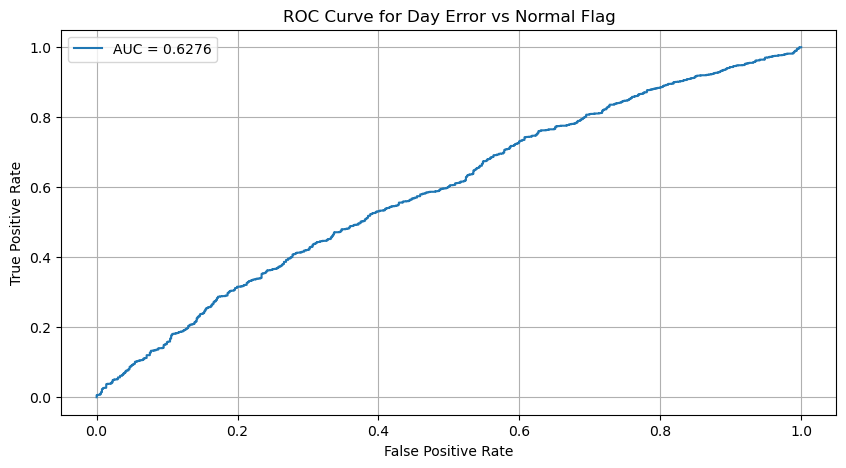

In [30]:
# visualize roc curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    sampleNorms, 1 - reconsError.cpu().numpy().max(axis=2).mean(axis=1)
)
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Day Error vs Normal Flag")
plt.legend()
plt.grid()
plt.show()

### Err histogram

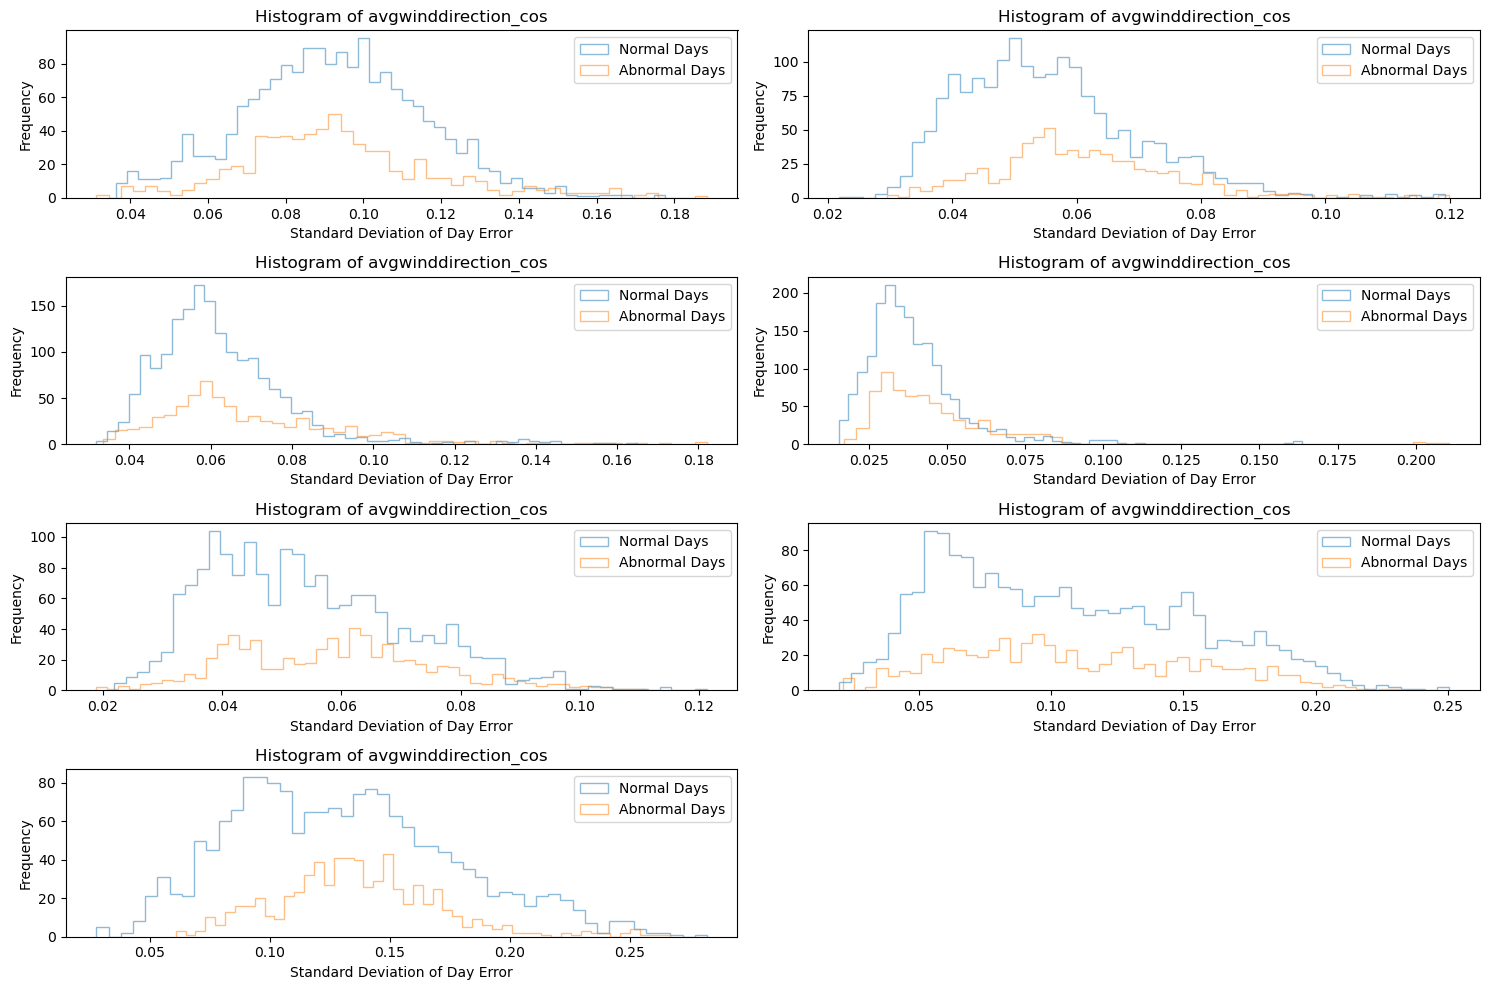

In [31]:
plt.figure(figsize=(15, 10))
for i in range(reconsError.size(1)):
    featDayErr = reconsError[:, i]  # (sample, timestep)
    # slice err to normal and abnormal days; dayNormal - (sample)
    normalDays = featDayErr[sampleNorms, :]
    abnormalDays = featDayErr[~np.array(sampleNorms), :]

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)

    plt.hist(
        normalDays.std(dim=1).cpu().numpy(),
        bins=50,
        alpha=0.5,
        histtype="step",
        label="Normal Days",
    )
    plt.hist(
        abnormalDays.std(dim=1).cpu().numpy(),
        bins=50,
        alpha=0.5,
        histtype="step",
        label="Abnormal Days",
    )

    plt.xlabel("Standard Deviation of Day Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title(f"Histogram of {feat}")
plt.tight_layout()
plt.show()

## AU-PR

AUPR: 0.6747137651571603


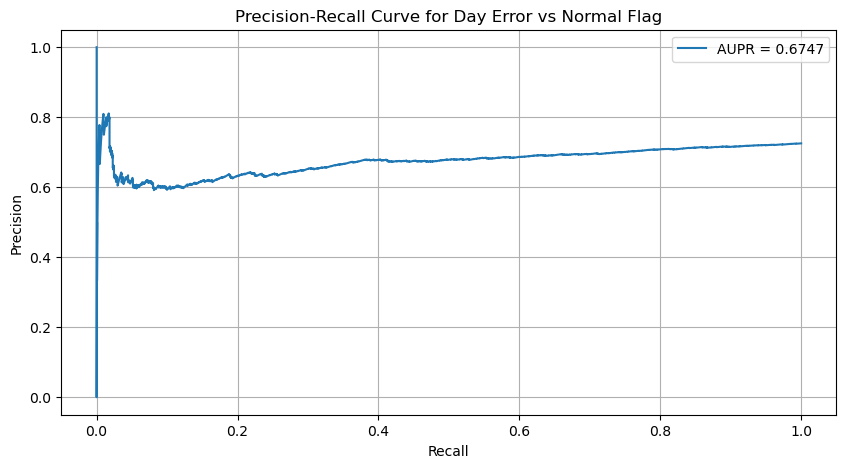

In [32]:
from sklearn.metrics import average_precision_score, precision_recall_curve

print(
    f"AUPR: {average_precision_score(sampleNorms, reconsError.cpu().numpy().max(axis=2).mean(axis=1))}"
)

precision, recall, _ = precision_recall_curve(
    sampleNorms, reconsError.cpu().numpy().max(axis=2).mean(axis=1)
)
plt.figure(figsize=(10, 5))
plt.plot(
    recall,
    precision,
    label=f"AUPR = {average_precision_score(sampleNorms, reconsError.cpu().numpy().max(axis=2).mean(axis=1)):.4f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Day Error vs Normal Flag")
plt.legend()
plt.grid()
plt.show()

## Predictive layer

In [33]:
from model_options.multihead.regressive_wrapper import SimpleRegressionModel


class PredictiveWrapper(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)

        self.ae = model
        self.predictor = SimpleRegressionModel(1)

        for param in self.ae.parameters():
            param.requires_grad = False  # the ae is trained

    def forward(self, x):
        reconst, *_ = self.ae(x)
        err = reconst - x

        flattenErr = err.reshape(err.size(0), -1)
        pred = self.predictor(flattenErr)
        return pred

In [34]:
def inferBatchPredict(batch, model):
    # reshapre to (batch, feats as channels, timesteps)
    inp = indexer.slice(batch, targetFeats, dim=1)

    label = indexer.slice(batch, ["normalbehaviour"], dim=1)
    # rm feat dim (d=1)  # (batch, 1)
    label = label.squeeze(1).sum(dim=1, keepdim=True) >= 127
    label = label.float()

    pred = model(inp)

    return pred, label

In [35]:
predModel = PredictiveWrapper()

predLoss = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(predModel.parameters(), lr=0.001)

predModel, trainLosses, valLosses, info = train(
    predModel,
    device,
    trainLoader,
    valLoader,
    predLoss,
    optimizer,
    epochs=num_epochs,
    earlyStopping=earlyStopping,
    inferBatch=inferBatchPredict,
    verbose=False,
)

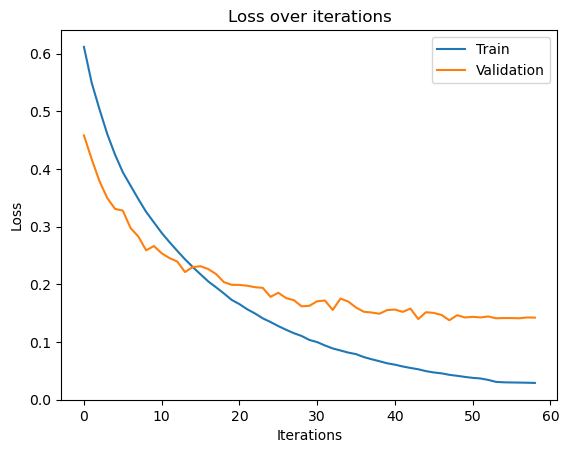

In [36]:
plt.plot(trainLosses[:])
plt.plot(valLosses[:])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("Loss over iterations")
plt.show()

Accuracy: 0.9178423236514522
Recall: 0.9426546391752577
Precision: 0.9306615776081425
F1 Score: 0.9366197183098591
ROC AUC: 0.9704314156633744
AUPR: 0.9827004993001485


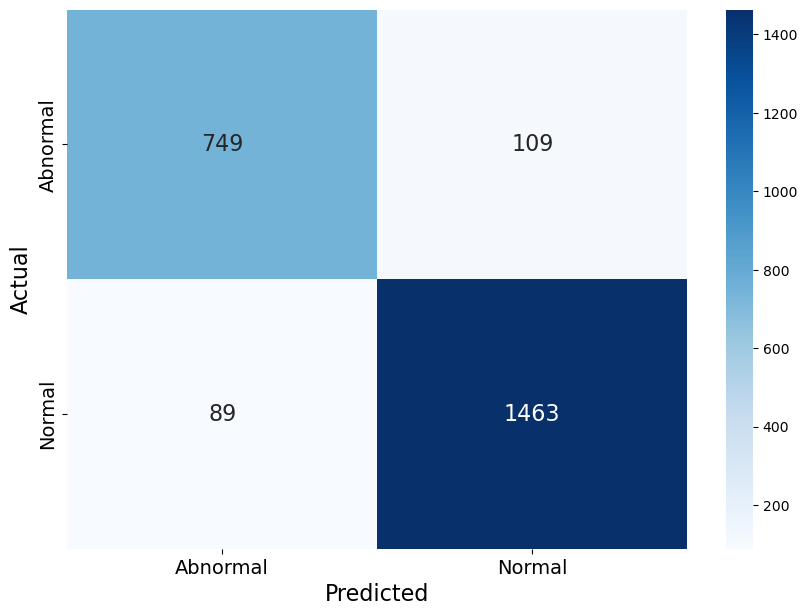

In [37]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)


pred, label = infer(predModel, device, testLoader, inferBatchPredict)

pred = torch.sigmoid(pred)

pred = pred.cpu().numpy().squeeze()
label = label.cpu().numpy().squeeze()

acc = accuracy_score(label, pred > 0.5)
recall = recall_score(label, pred > 0.5)
prec = precision_score(label, pred > 0.5)
f1 = f1_score(label, pred > 0.5)
roc_auc = roc_auc_score(label, pred)
aupr = average_precision_score(label, pred)

print(f"Accuracy: {acc}")
print(f"Recall: {recall}")
print(f"Precision: {prec}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"AUPR: {aupr}")

confusion = confusion_matrix(label, pred > 0.5)
plt.figure(figsize=(10, 7))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 16},
    xticklabels=["Abnormal", "Normal"],
    yticklabels=["Abnormal", "Normal"],
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.title("Confusion Matrix for Predictive Model")
plt.show()

### Explaining

In [39]:
# # Get weights (PyTorch stores weights as [out_features, in_features])
# weights = model.regressionModel.fc.weight.data.cpu().numpy()  # (32, 64)
# weights = weights.reshape(32, 4, 16) 


# fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# for channel in range(4):
#     channel_weights = weights[:, channel, :]  
    
#     # Plot heatmap
#     ax = axes[channel]
#     im = ax.imshow(channel_weights, cmap='coolwarm', aspect='auto')
#     ax.set_title(f'Input Channel {channel} to Hidden Layer')
#     ax.set_xlabel('Input Feature (within channel)')
#     ax.set_ylabel('Hidden Neuron Index')
#     plt.colorbar(im, ax=ax)
# plt.tight_layout()
# plt.show()


In [40]:
# # Get weights (PyTorch stores weights as [out_features, in_features])
# weights = (
#     model.regressionModel.out.weight.data.cpu()
# )  # Shape: (32, 128) [since input is flattened 4*32=128]

# # Reshape weights to match input structure (if applicable, e.g., 4 features × 32 timesteps)
# plt.figure(figsize=(10, 6))
# plt.imshow(weights, cmap="coolwarm", aspect="auto")
# plt.colorbar()
# plt.xlabel("Input Features (Flattened)")
# plt.ylabel("Neurons in Hidden Layer")
# plt.title("Weight Matrix Heatmap")
# plt.show()